In [19]:
# %matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN = "#18453B" 

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# The 1D Ideal MHD Equations

\begin{equation}\tag{1}
\mathbf{U}_t + \mathbf{F}(\mathbf{U})_x = 0
\end{equation}


\begin{equation}\tag{2}
\mathbf{U} =
\begin{pmatrix}
\rho \\
\rho u_x \\
\rho u_y \\
\rho u_z \\
E \\
B_x \\
B_y \\
B_z \\
\end{pmatrix},
\qquad
\mathbf{F}(\mathbf{U}) =
\begin{pmatrix}
\rho u_x \\
\rho u_x^2 + p + \frac{1}{2}\|\mathbf{B}\|^2 - B_x^2 \\
\rho u_x u_y - B_x B_y \\
\rho u_x u_z - B_x B_z \\
u_x \left(E + p + \frac{1}{2}\|\mathbf{B}\|^2 \right) - B_x (\mathbf{u}\cdot\mathbf{B}) \\
0 \\
u_x B_y - u_y B_x \\
u_x B_z - u_z B_x 
\end{pmatrix}
\end{equation}

The conserved variables are:

- mass density: $\rho(x,t)$  
- momentum density: $\rho \textbf{u} (x,t)  = (\rho u_x, \rho u_y, \rho u_z)$  
- energy density: $E(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The primitive (physical) variables are:

- density: $\rho(x,t)$  
- velocity: $\textbf{u}(x,t) = (u_x, u_y, u_z)$  
- pressure: $p(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The total energy density is given as:

\begin{equation}\tag{3}
E = \frac{p}{\gamma - 1} + \frac{1}{2} \rho \|\mathbf{u}\|^2  + \frac{1}{2} \|\mathbf{B}\|^2
\end{equation}

where $\gamma$ is the adiabatic index

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#number of ghost cells for Bcs
nghost = 2

# degrees of freedom for solution vector
DOFs_MHD_1D = 8

In [22]:
# Initial conditions
def Brio_Wu(x, gamma=2.0): #returns conservative form
    if 0 <= x < 0.5:
        rho_init = 1.0
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 1.0
        bx_init = 0.75
        by_init = 1.0
        bz_init = 0.0
    elif 0.5 <= x <= 1:
        rho_init = 0.125
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 0.1
        bx_init = 0.75
        by_init = -1.0
        bz_init = 0.0
    else:
        print('error in Brio Wu IC')
    
    rho = rho_init
    rho_ux = rho_init * ux_init
    rho_uy = rho_init * uy_init
    rho_uz = rho_init * uz_init
    #-------- compute energy ------------
    KE = 0.5*rho*(ux_init**2 + uy_init**2 + uz_init**2)
    ME = 0.5*(bx_init**2 + by_init**2 + bz_init**2)
    E = p_init/(gamma - 1) + KE + ME
    # ----------------------------------
    bx = bx_init
    by = by_init
    bz = bz_init
    
    U_element = np.array([rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz])
    return U_element 

def Dai_Woodward(x, gamma=5/3): #returns conservative form
    if 0 <= x < 0.5:
        rho_init = 1.08
        ux_init = 1.2
        uy_init = 0.01
        uz_init = 0.5
        p_init = 0.95
        bx_init = 2/np.sqrt(4*np.pi)
        by_init = 3.6/np.sqrt(4*np.pi)
        bz_init = 2/np.sqrt(4*np.pi)
    elif 0.5 <= x <= 1:
        rho_init = 1.0
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 1.0
        bx_init = 2/np.sqrt(4*np.pi)
        by_init = 4/np.sqrt(4*np.pi)
        bz_init = 2/np.sqrt(4*np.pi)
    else:
        print('error in Dai Woodward IC')
    
    rho = rho_init
    rho_ux = rho_init * ux_init
    rho_uy = rho_init * uy_init
    rho_uz = rho_init * uz_init
    #-------- compute energy ------------
    KE = 0.5*rho*(ux_init**2 + uy_init**2 + uz_init**2)
    ME = 0.5*(bx_init**2 + by_init**2 + bz_init**2)
    E = p_init/(gamma - 1) + KE + ME
    # ----------------------------------
    bx = bx_init
    by = by_init
    bz = bz_init
    
    U_element = np.array([rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz])
    return U_element 


In [23]:
# Outflow BC: 

def fill_ghost_outflow_bc(U,nx):
    # left boundary
    for i in range(DOFs_MHD_1D):
        U[i, 0:nghost] = U[i, nghost]
        
        #right boundary
        U[i, nghost+nx:] = U[i, nghost+nx-1]
    
    return U



In [24]:
# conservative form to primitive form helper function

# takes in U(rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)
# returns  U(rho, ux,     uy,     uz,     p, bx, by, bz)
def cons_to_prim(U, gamma):
    # grab conservative variables
    rho_cons      = U[0]
    rho_ux_cons   = U[1]
    rho_uy_cons   = U[2]
    rho_uz_cons   = U[3]
    E_cons        = U[4]
    bx_cons       = U[5]
    by_cons       = U[6]
    bz_cons       = U[7]
    
    # new solution vector to return
    U_prim = np.zeros_like(U)
    
    #pull out primitive variables
    rho_prim = rho_cons
    ux_prim  = rho_ux_cons/rho_cons
    uy_prim  = rho_uy_cons/rho_cons
    uz_prim  = rho_uz_cons/rho_cons
    E_prim   = E_cons
    bx_prim  = bx_cons
    by_prim  = by_cons
    bz_prim  = bz_cons
    
    KE = 0.5*rho_prim*(ux_prim**2 + uy_prim**2 + uz_prim**2)
    ME = 0.5*(bx_prim**2 + by_prim**2 + bz_prim**2)
    
    p_prim = (gamma - 1.0) * (E_prim - KE - ME)

    #assign primitive variables inside new U
    U_prim[0] = rho_prim
    U_prim[1] = ux_prim
    U_prim[2] = uy_prim
    U_prim[3] = uz_prim
    U_prim[4] = p_prim
    U_prim[5] = bx_prim
    U_prim[6] = by_prim
    U_prim[7] = bz_prim
    
    return U_prim

# primitive form to conservative form helper function
# takes in  U(rho, ux,     uy,     uz,     p, bx, by, bz)
# returns   U(rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)
def prim_to_cons(U, gamma):
    # grab primative variables
    rho_prim  = U[0]
    ux_prim   = U[1]
    uy_prim   = U[2]
    uz_prim   = U[3]
    p_prim    = U[4]
    bx_prim   = U[5]
    by_prim   = U[6]
    bz_prim   = U[7]    

    #--------- get energy from pressure ---------------
    KE = 0.5*rho_prim*(ux_prim**2 + uy_prim**2 + uz_prim**2)
    ME = 0.5*(bx_prim**2 + by_prim**2 + bz_prim**2)    

    E_cons   = p_prim/(gamma-1) + KE + ME
    #--------------------------------------------------

    # new solution vector to return
    U_cons = np.zeros_like(U)
    
    #pull out primitive variables
    rho_cons      = rho_prim
    rho_ux_cons   = rho_prim*ux_prim
    rho_uy_cons   = rho_prim*uy_prim
    rho_uz_cons   = rho_prim*uz_prim
    E_cons        = E_cons
    bx_cons       = bx_prim
    by_cons       = by_prim
    bz_cons       = bz_prim  
    

    #assign primitive variables inside new U
    U_cons[0] = rho_cons
    U_cons[1] = rho_ux_cons
    U_cons[2] = rho_uy_cons
    U_cons[3] = rho_uz_cons
    U_cons[4] = E_cons
    U_cons[5] = bx_cons
    U_cons[6] = by_cons
    U_cons[7] = bz_cons
    
    return U_cons



In [25]:
# setup function that computes the flux eqn. 8.55

def compute_flux(q, gamma):
    q_prim = cons_to_prim(q, gamma)
    
    rho  = q_prim[0]
    ux   = q_prim[1]
    uy   = q_prim[2]
    uz   = q_prim[3]
    p    = q_prim[4]
    bx   = q_prim[5]
    by   = q_prim[6]
    bz   = q_prim[7]
    
    E = p/(gamma-1) + 0.5*rho*(ux**2 + uy**2 + uz**2) + 0.5*(bx**2 + by**2 + bz**2)
    
    F = np.zeros_like(q)
    F[0] = rho * ux
    F[1] = rho*(ux**2) + p + 0.5*(bx**2 + by**2 + bz**2) - bx**2
    F[2] = rho*ux*uy - bx*by
    F[3] = rho*ux*uz - bx*bz
    F[4] = ux*(E + p + 0.5*(bx**2 + by**2 + bz**2)) - bx*(ux*bx + uy*by + uz*bz)
    F[5] = 0
    F[6] = ux*by - uy*bx
    F[7] = ux*bz - uz*bx
    
    return F


# Riemann Solver

modeled after Carolyn's code

In [26]:
def Riemann_HLL(U_L, U_R, gamma):
    U_L_cons = U_L.copy()
    U_R_cons = U_R.copy()
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L  = U_L_prim[0]
    ux_L   = U_L_prim[1]
    uy_L   = U_L_prim[2]
    uz_L   = U_L_prim[3]
    p_L    = U_L_prim[4]
    bx_L   = U_L_prim[5]
    by_L   = U_L_prim[6]
    bz_L   = U_L_prim[7]
    
    rho_R  = U_R_prim[0]
    ux_R   = U_R_prim[1]
    uy_R   = U_R_prim[2]
    uz_R   = U_R_prim[3]
    p_R    = U_R_prim[4]
    bx_R   = U_R_prim[5]
    by_R   = U_R_prim[6]
    bz_R   = U_R_prim[7]
    
    #--------- compute fastest wave speed ---------------
    # c^2 (sound speed)
    c2_L = gamma*p_L/rho_L
    c2_R = gamma*p_R/rho_R
    
    # ||B||^2 (magnetic field magnitude)
    b2_L = bx_L**2 + by_L**2 + bz_L**2
    b2_R = bx_R**2 + by_R**2 + bz_R**2
    
    # term 1 = c^2 + ||B||^2 / rho
    term1_L = c2_L + b2_L/rho_L
    term1_R = c2_R + b2_R/rho_R
    
    # term 2 = sqrt( term1^2 - 4* c^2 * (bx^2 / rho))
    term2_L = np.sqrt(term1_L**2 - 4*c2_L *(bx_L**2 / rho_L))
    term2_R = np.sqrt(term1_R**2 - 4*c2_R *(bx_R**2 / rho_R)) 
    
    # c_f (fast magnetosonic wave speed)
    cf_L = np.sqrt(0.5*(term1_L + term2_L))
    cf_R = np.sqrt(0.5*(term1_R + term2_R))

    # determine left and rightmost e.vals
    s_l = min(ux_L - cf_L, ux_R - cf_R)
    s_r = max(ux_L + cf_L, ux_R + cf_R)
    
    # get the conserved state and fluxes (U_L and U_R are already conservative form)
    
    F_L = compute_flux(U_L_cons, gamma)
    F_R = compute_flux(U_R_cons, gamma)
    
    # determine HLL Flux
    
    if s_l >=0:
        flux = F_L
    elif s_r <=0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R - U_L)) / (s_r - s_l)
    
    return flux
    

# HLLC Riemann Solver

Toro's book

# This doesn't work. Toro's book describes HLLC for Euler's, so probably for MHD a different method is needed or I'm misunderstanding something. 

# I will leave it here though incase it comes in handy later.

In [27]:
'''
def U_star_s(U_s, rho_s, ux_s, uy_s, uz_s, p_s, E_s, bx_s, by_s, bz_s, S_s, S_star): #10.4.3 in Toro explains this, we use eqn (10.46)
    U_star_s = np.zeros_like(U_s)
    
    factor = rho_s * (S_s - ux_s)/(S_s - S_star)
    
    U_star_s[0] = factor
    U_star_s[1] = factor * S_star
    U_star_s[2] = factor * uy_s
    U_star_s[3] = factor * uz_s
    U_star_s[4] = factor * (E_s/rho_s + (S_star - ux_s)*(S_star + p_s/(rho_s*(S_s - ux_s)))) # (10.39 Toro)
    U_star_s[5] = bx_s
    U_star_s[6] = factor * by_s / rho_s
    U_star_s[7] = factor * bz_s / rho_s
    
    return U_star_s

def Riemann_HLLC(U_L, U_R, gamma):
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L  = U_L_prim[0]
    ux_L   = U_L_prim[1]
    uy_L   = U_L_prim[2]
    uz_L   = U_L_prim[3]
    p_L    = U_L_prim[4]
    bx_L   = U_L_prim[5]
    by_L   = U_L_prim[6]
    bz_L   = U_L_prim[7]
    
    rho_R  = U_R_prim[0]
    ux_R   = U_R_prim[1]
    uy_R   = U_R_prim[2]
    uz_R   = U_R_prim[3]
    p_R    = U_R_prim[4]
    bx_R   = U_R_prim[5]
    by_R   = U_R_prim[6]
    bz_R   = U_R_prim[7]
    
    #--------- compute fastest wave speed -----------------
    # c^2 (sound speed)
    c2_L = gamma*p_L/rho_L
    c2_R = gamma*p_R/rho_R
    
    # ||B||^2 (magnetic field magnitude)
    b2_L = bx_L**2 + by_L**2 + bz_L**2
    b2_R = bx_R**2 + by_R**2 + bz_R**2
    
    # term 1 = c^2 + ||B||^2 / rho
    term1_L = c2_L + b2_L/rho_L
    term1_R = c2_R + b2_R/rho_R
    
    # term 2 = sqrt( term1^2 - 4* c^2 * (bx^2 / rho))
    term2_L = np.sqrt(term1_L**2 - 4*c2_L *(bx_L**2 / rho_L))
    term2_R = np.sqrt(term1_R**2 - 4*c2_R *(bx_R**2 / rho_R)) 
    
    # c_f (fast magnetosonic wave speed)
    cf_L = np.sqrt(0.5*(term1_L + term2_L))
    cf_R = np.sqrt(0.5*(term1_R + term2_R))
    #--------------------------------------------------------
    
    # determine left and rightmost e.vals and S*
    S_L    = min(ux_L - cf_L, ux_R - cf_R)
    S_R    = max(ux_L + cf_L, ux_R + cf_R)
    p_tot_L = p_L + 0.5*(by_L**2 + bz_L**2)
    p_tot_R = p_R + 0.5*(by_R**2 + bz_R**2)
    S_star = (p_tot_R - p_tot_L + rho_L * ux_L * (S_L - ux_L) - rho_R * ux_R * (S_R - ux_R)) / (rho_L*(S_L-ux_L) - rho_R*(S_R-ux_R)) # (10.37 Toro)
    
    # get the conserved state and fluxes (U_L and U_R are already conservative form)
    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)
    
    # get E_L and E_R for U* computations
    E_L = U_L[4]
    E_R = U_R[4]
    
    # comptue U* and F* for left and right
    U_star_L = U_star_s(U_L, rho_L, ux_L, uy_L, uz_L, p_L, E_L, bx_L, by_L, bz_L, S_L, S_star)
    F_star_L = F_L + S_L*(U_star_L - U_L) # (10.38 Toro)
    
    U_star_R = U_star_s(U_R, rho_R, ux_R, uy_R, uz_R, p_R, E_R, bx_R, by_R, bz_R, S_R, S_star)
    F_star_R = F_R + S_R*(U_star_R - U_R) # (10.38 Toro)
    
    # determine HLLC Flux
    
    if S_L >=0:
        flux = F_L
    elif (S_L<=0<=S_star):
        flux = F_star_L
    elif (S_star<=0<=S_R):
        flux = F_star_R
    else:
        flux = F_R
    
    return flux
'''

'\ndef U_star_s(U_s, rho_s, ux_s, uy_s, uz_s, p_s, E_s, bx_s, by_s, bz_s, S_s, S_star): #10.4.3 in Toro explains this, we use eqn (10.46)\n    U_star_s = np.zeros_like(U_s)\n\n    factor = rho_s * (S_s - ux_s)/(S_s - S_star)\n\n    U_star_s[0] = factor\n    U_star_s[1] = factor * S_star\n    U_star_s[2] = factor * uy_s\n    U_star_s[3] = factor * uz_s\n    U_star_s[4] = factor * (E_s/rho_s + (S_star - ux_s)*(S_star + p_s/(rho_s*(S_s - ux_s)))) # (10.39 Toro)\n    U_star_s[5] = bx_s\n    U_star_s[6] = factor * by_s / rho_s\n    U_star_s[7] = factor * bz_s / rho_s\n\n    return U_star_s\n\ndef Riemann_HLLC(U_L, U_R, gamma):\n    # get primitive form for easier computation\n    U_L_prim = cons_to_prim(U_L, gamma)\n    U_R_prim = cons_to_prim(U_R, gamma)\n\n    rho_L  = U_L_prim[0]\n    ux_L   = U_L_prim[1]\n    uy_L   = U_L_prim[2]\n    uz_L   = U_L_prim[3]\n    p_L    = U_L_prim[4]\n    bx_L   = U_L_prim[5]\n    by_L   = U_L_prim[6]\n    bz_L   = U_L_prim[7]\n\n    rho_R  = U_R_prim[0]\n

In [28]:
def piecewise_constant(U):
    return U, U

In [29]:
def minmod(a, b): #vectorized like Carolyn's so input can be vector valued
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

def compute_interface_states_PLM(U, dx, dt):
    n = len(U[0])
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,i+1] - U[:,i]              # forward difference
        dr = U[:,i] - U[:,i-1]              # backward difference

        slope = minmod(dl, dr)

        U_L[:,i] = U[:,i] + 0.5 * slope
        U_R[:,i] = U[:,i] - 0.5 * slope

    return U_L, U_R

def piecewise_linear(U, dx, dt):
    U_L, U_R = compute_interface_states_PLM(U, dx, dt)
    return U_L, U_R

In [30]:
# need to find the fastest wave so we can compute
# a proper time step in evolve()

def eigenvalues(U, gamma): # takes primative U
    rho  = U[0]
    ux   = U[1]
    uy   = U[2]
    uz   = U[3]
    p    = U[4]
    bx   = U[5]
    by   = U[6]
    bz   = U[7]
    
    # compute sound speed
    
    c = np.sqrt(gamma*p/rho)
    
    # compute Alfven speed
    ca = np.sqrt((bx**2 + by**2 + bz**2) / rho)
    cax = np.abs(np.sqrt(bx**2 / rho))
    
    # compute fast MS wave speed
    cf = np.sqrt(0.5*np.abs(c**2 + ca**2 + np.sqrt((c**2 + ca**2)**2 - (4*c**2 * cax**2))))
    
    # compute slow MS wave speed
    cs = np.sqrt(0.5*np.abs(c**2 + ca**2 - np.sqrt((c**2 + ca**2)**2 - (4*c**2 * cax**2))))
    
    # find maximum wave speed
    
    em = 1.0e-15
    
    max_eigen_1 = max(em, np.max(np.abs(ux - cf )))
    max_eigen_2 = max(em, np.max(np.abs(ux - cax)))
    max_eigen_3 = max(em, np.max(np.abs(ux - cs )))
    max_eigen_4 = max(em, np.max(np.abs(ux      )))
    max_eigen_5 = max(em, np.max(np.abs(ux      )))
    max_eigen_6 = max(em, np.max(np.abs(ux + cs )))
    max_eigen_7 = max(em, np.max(np.abs(ux + cax)))
    max_eigen_8 = max(em, np.max(np.abs(ux + cf )))

    alpha = np.array([max_eigen_1, max_eigen_2 , max_eigen_3, max_eigen_4, max_eigen_5, max_eigen_6, max_eigen_7, max_eigen_8])
    
    return alpha

In [31]:

def evolve(U_ghosted, nx, C, t_final, gamma, Riemann, Godunov_type):
    dx = 1.0 / nx

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    nt = 0 # time step counter
    
    all_solns.append(U[:, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:
        
        # fill ghost cells with outflow BC
        fill_ghost_outflow_bc(U, nx)
        
        # get the timestep based on the CFL condition, but also make sure we don't step past t_final
        U_prim = cons_to_prim(U[:, nghost:nghost+nx], gamma) #U(rho, U, p, B)
        # get alpha and find maximum speed for time step
        alpha = eigenvalues(U_prim, gamma)
        dt = C * dx / max(alpha)  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #get the interface states using the specified reconstruction method
        if Godunov_type == 0: # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
            U_L, U_R = piecewise_constant(U)
        if Godunov_type == 1:
            U_L, U_R = piecewise_linear(U, dx, dt)
        
        # do the update
        F = np.zeros_like(U)
        
        for i in range(nghost-1, nghost+nx):
            F[:,i] = Riemann(U_L[:, i], U_R[:, i+1], gamma) # returns flux of conservative state
        
        
        for i in range(nghost, nghost+nx):
            U[:, i] = U[:, i] - (dt/dx) * (F[:, i] - F[:, i-1])
        t += dt
        nt += 1
        if nt % 100 == 0: 
            print(f"Step: {nt}, Time: {t:.3f}") # Print Every 100 Time Steps
            
        all_solns.append(U[:, nghost:nghost+nx].copy())
        all_t.append(t)

    print(f"Finished at Step: {nt}, Time: {t:.3f}")
    return U[:, nghost:nghost+nx], all_solns, all_t

In [32]:
def plot_solution(grid, U_Sol, t, gamma, case='Brio-Wu', Godonuv_type='Piecewise Constant', Riemann='HLL'):
    '''
    Definition: plots density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid  : array of x coordinates
                q_sys : conserved variables (ρ, ρU, E, B)^T
                t     : current time
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    matplotlib figure showing Euler quantities

    '''

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)
    
    U_Sol_prim = cons_to_prim(U_Sol, gamma)
    
    rho_sol = U_Sol_prim[0]
    ux_sol = U_Sol_prim[1]
    uy_sol = U_Sol_prim[2]
    uz_sol = U_Sol_prim[3]
    p_sol = U_Sol_prim[4]
    E_sol = U_Sol[4]
    bx_sol = U_Sol_prim[5]
    by_sol = U_Sol_prim[6]
    bz_sol = U_Sol_prim[7]

    
    
    fig, plots = plt.subplots(2, 3, figsize=(18, 8), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = 'lavender'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 0.8

    CE = 'k' 

    # Top Left Plot
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
    plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Godonuv_type} \n {Riemann}')
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 
    plots[0][0].legend(fontsize=10) 
    
    # Bottom Left Plot
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

    # Top middle Plot
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, ux_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

    # Bottom middle Plot
    plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, uy_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][1].set_title(r'$v_y$')
    plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])
    
    # Top right Plot
    plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
    plots[0][2].plot(grid, by_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][2].set_title(r'$B_y$')
    plots[0][2].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

    # Bottom right Plot
    plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][2].plot(grid, E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][2].set_title('Total Energy')
    plots[1][2].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [33]:
def movie_maker(grid, all_solns, all_t, gamma, Riemann_type, case):
    '''
    Definition: creates a movie of the 1D Euler solution: 
                density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid      : array of x coordinates
                all_solns : list of conserved variable arrays (ρ, ρU, E, B)^T at each time step
                all_t     : array of all time steps
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    movie showing Euler quantities

    '''

    n_steps = len(all_t)

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

    # Create a figure and axis for plotting
    fig, plots = plt.subplots(2, 3, figsize=(18, 10), dpi=200)

    def animate(i):
        ''' function to update the plot for each frame  '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()
        plots[0][2].clear()
        plots[1][2].clear()

        t = all_t[i]
        U_frame = all_solns[i]  # get the i-th snapshot

        U_Sol_prim = cons_to_prim(U_frame, gamma)
        
        rho_sol = U_Sol_prim[0]
        ux_sol = U_Sol_prim[1]
        uy_sol = U_Sol_prim[2]
        uz_sol = U_Sol_prim[3]
        p_sol = U_Sol_prim[4]
        E_sol = U_frame[4]
        bx_sol = U_Sol_prim[5]
        by_sol = U_Sol_prim[6]
        bz_sol = U_Sol_prim[7]
        
        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.color'] = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k' 

        # Top Left Plot
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
        plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Riemann_type}')
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 
        plots[0][0].legend(fontsize=10) 
        
        # Bottom Left Plot
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

        # Top middle Plot
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, ux_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

        # Bottom middle Plot
        plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, uy_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][1].set_title(r'$v_y$')
        plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])
        
        # Top right Plot
        plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
        plots[0][2].plot(grid, by_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][2].set_title(r'$B_y$')
        plots[0][2].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

        # Bottom right Plot
        plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][2].plot(grid, E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][2].set_title(r'$Total Energy$')
        plots[1][2].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

    # Create the animation using matplotlib's FuncAnimation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    # Save the animation as a video file
    ani.save(f"{case}.gif", writer='pillow', fps=30, dpi=100)

Step: 100, Time: 0.005
Step: 200, Time: 0.011
Step: 300, Time: 0.016
Step: 400, Time: 0.021
Step: 500, Time: 0.026
Step: 600, Time: 0.031
Step: 700, Time: 0.036
Step: 800, Time: 0.041
Step: 900, Time: 0.046
Step: 1000, Time: 0.052
Step: 1100, Time: 0.057
Step: 1200, Time: 0.062
Step: 1300, Time: 0.067
Step: 1400, Time: 0.072
Step: 1500, Time: 0.077
Step: 1600, Time: 0.082
Step: 1700, Time: 0.088
Step: 1800, Time: 0.093
Step: 1900, Time: 0.098
Finished at Step: 1943, Time: 0.100


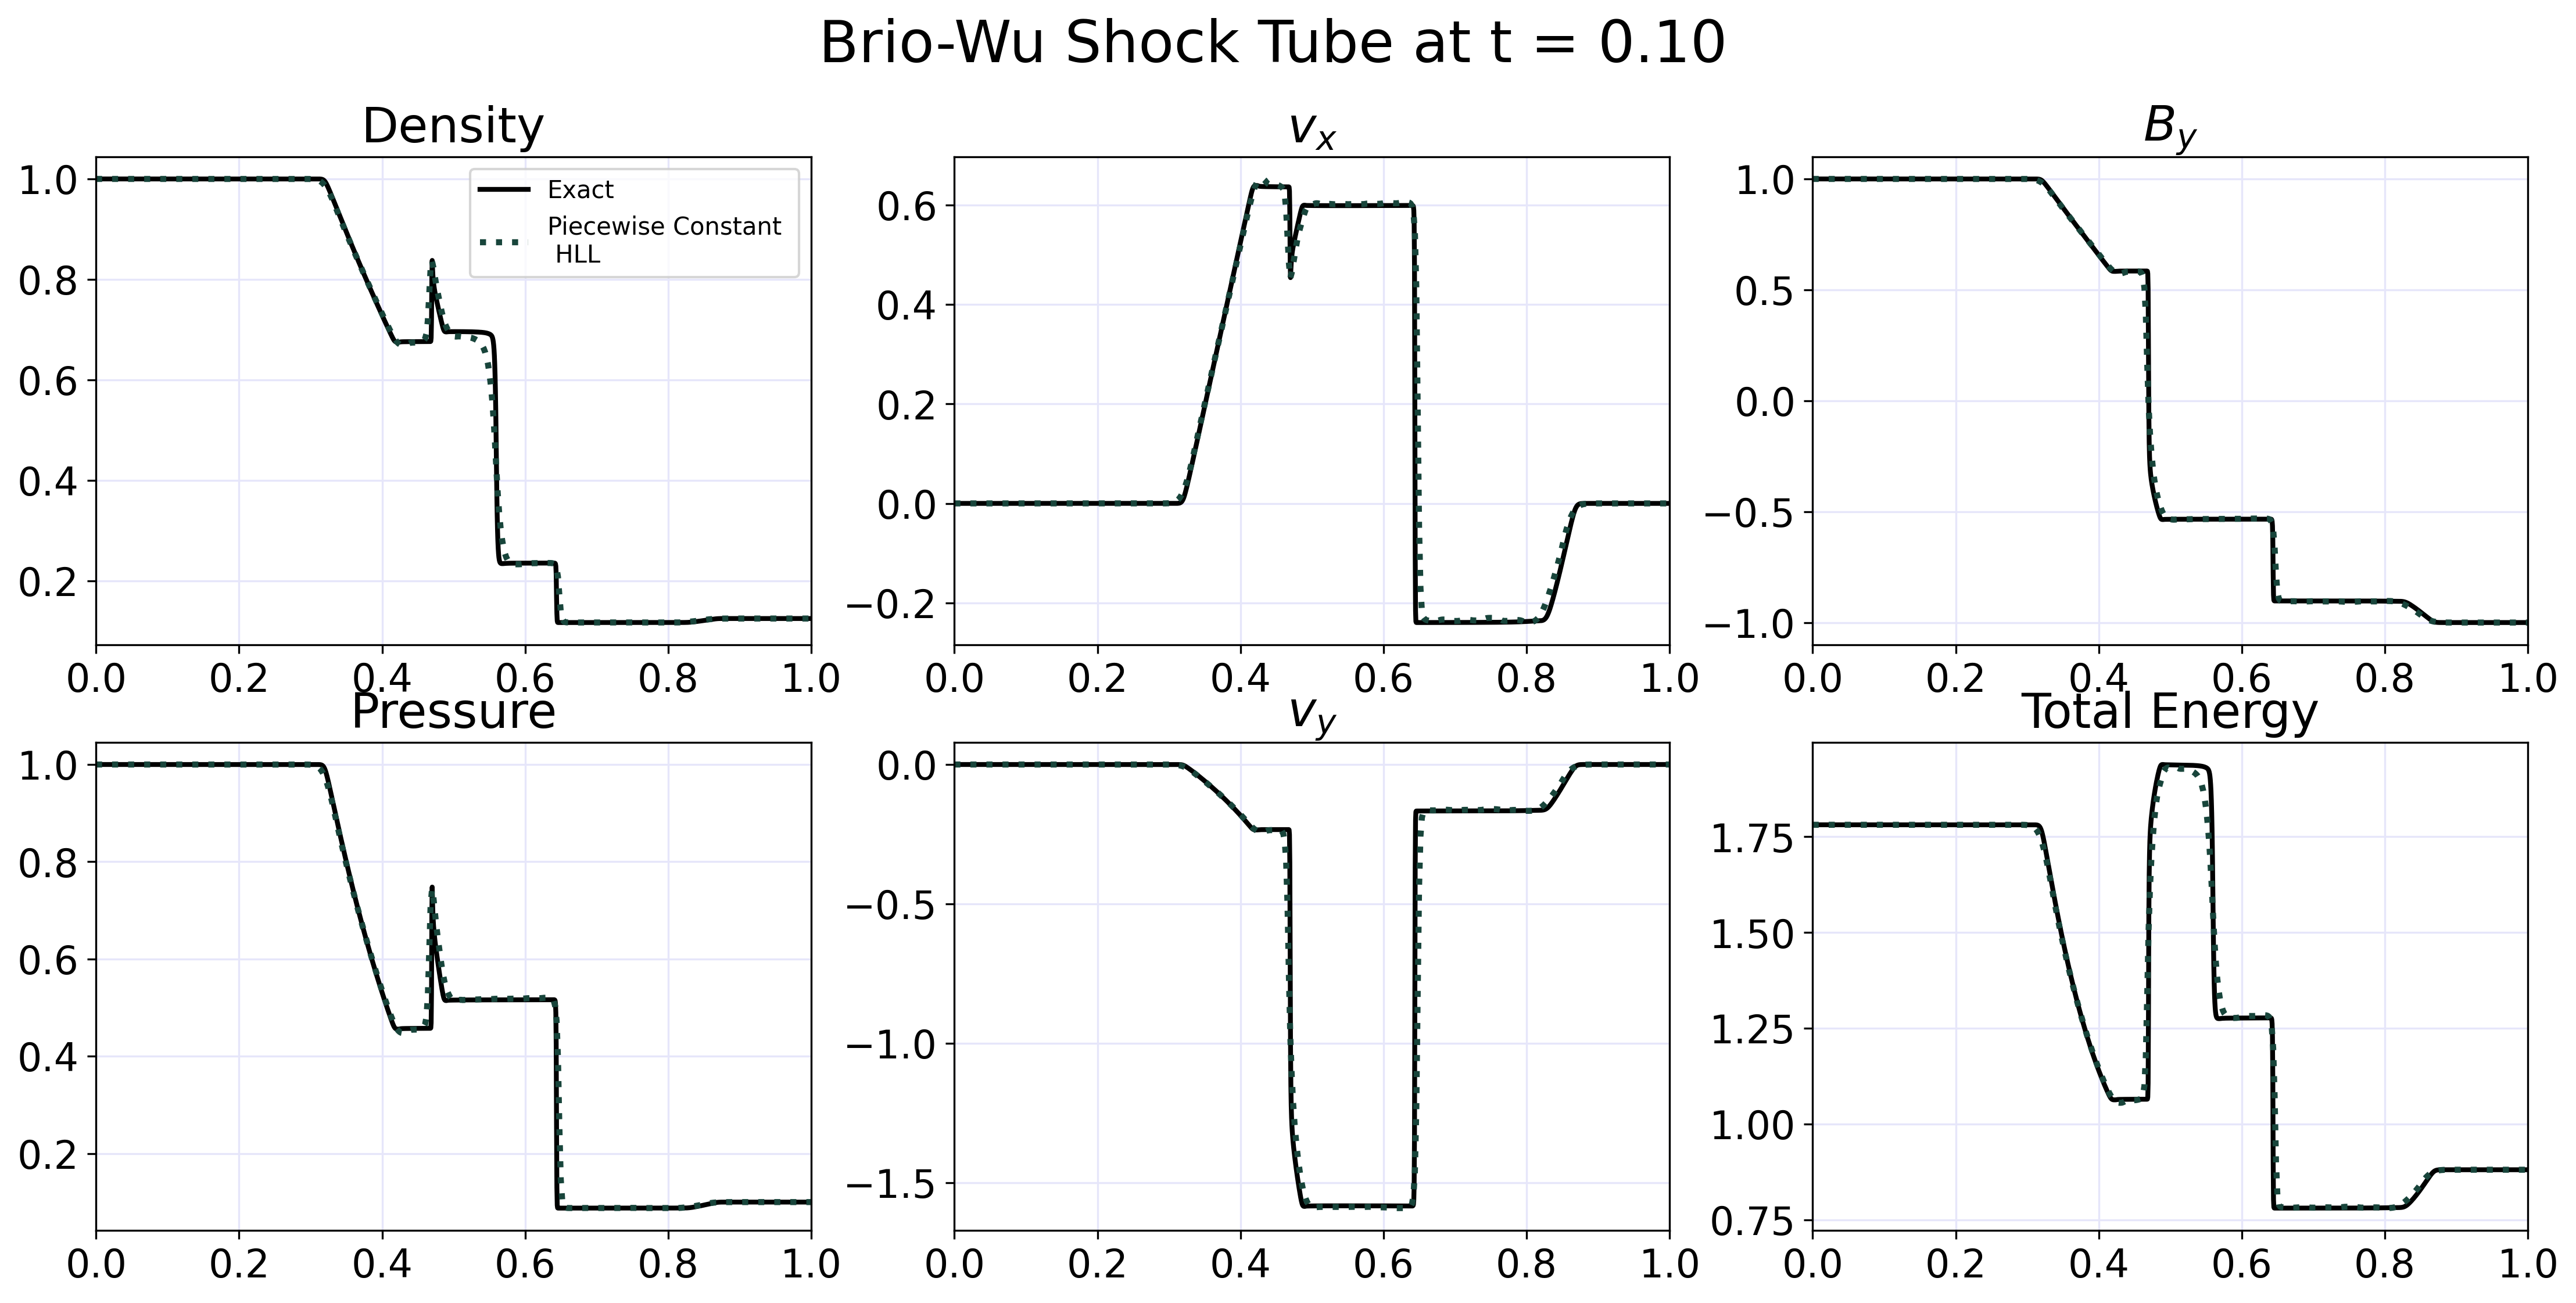

In [34]:
# Brio-Wu problem setting up variables and visualizing

DOFs_MHD_1D = 8
nx = 512
dx = 1/nx
C = 0.1
#Brio-Wu
gamma = 2.0
tf = 0.1

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_BW = np.array([Brio_Wu(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_BW = U_IC_BW.T # shape (DOF, nx)
U_ghost_IC_BW = np.zeros((DOFs_MHD_1D, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_BW[:, nghost:nghost+nx] = U_IC_BW # ghosted vector able to have BCs


U_Sol_BW_g1_HLL, all_solns_BW_g1_HLL, all_t_BW_g1_HLL    = evolve(U_ghost_IC_BW, nx, C, tf, gamma, Riemann_HLL, Godunov_type=1)


plot_solution(X, U_Sol_BW_g1_HLL, tf, gamma, 'Brio-Wu', 'Piecewise Constant', 'HLL')




# $\Downarrow$ Make a Movie $\Downarrow$
Takes ~30 min to run for n_points = 1024

In [35]:
#movie_maker(X, all_solns_BW_g1_HLL, all_t_BW_g1_HLL, gamma, 'HLL', 'Brio-Wu')

Step: 100, Time: 0.007
Step: 200, Time: 0.014
Step: 300, Time: 0.020
Step: 400, Time: 0.027
Step: 500, Time: 0.034
Step: 600, Time: 0.041
Step: 700, Time: 0.047
Step: 800, Time: 0.054
Step: 900, Time: 0.061
Step: 1000, Time: 0.068
Step: 1100, Time: 0.074
Step: 1200, Time: 0.081
Step: 1300, Time: 0.088
Step: 1400, Time: 0.095
Step: 1500, Time: 0.101
Step: 1600, Time: 0.108
Step: 1700, Time: 0.115
Step: 1800, Time: 0.122
Step: 1900, Time: 0.128
Step: 2000, Time: 0.135
Step: 2100, Time: 0.142
Step: 2200, Time: 0.149
Step: 2300, Time: 0.155
Step: 2400, Time: 0.162
Step: 2500, Time: 0.169
Step: 2600, Time: 0.176
Step: 2700, Time: 0.182
Step: 2800, Time: 0.189
Step: 2900, Time: 0.196
Finished at Step: 2961, Time: 0.200


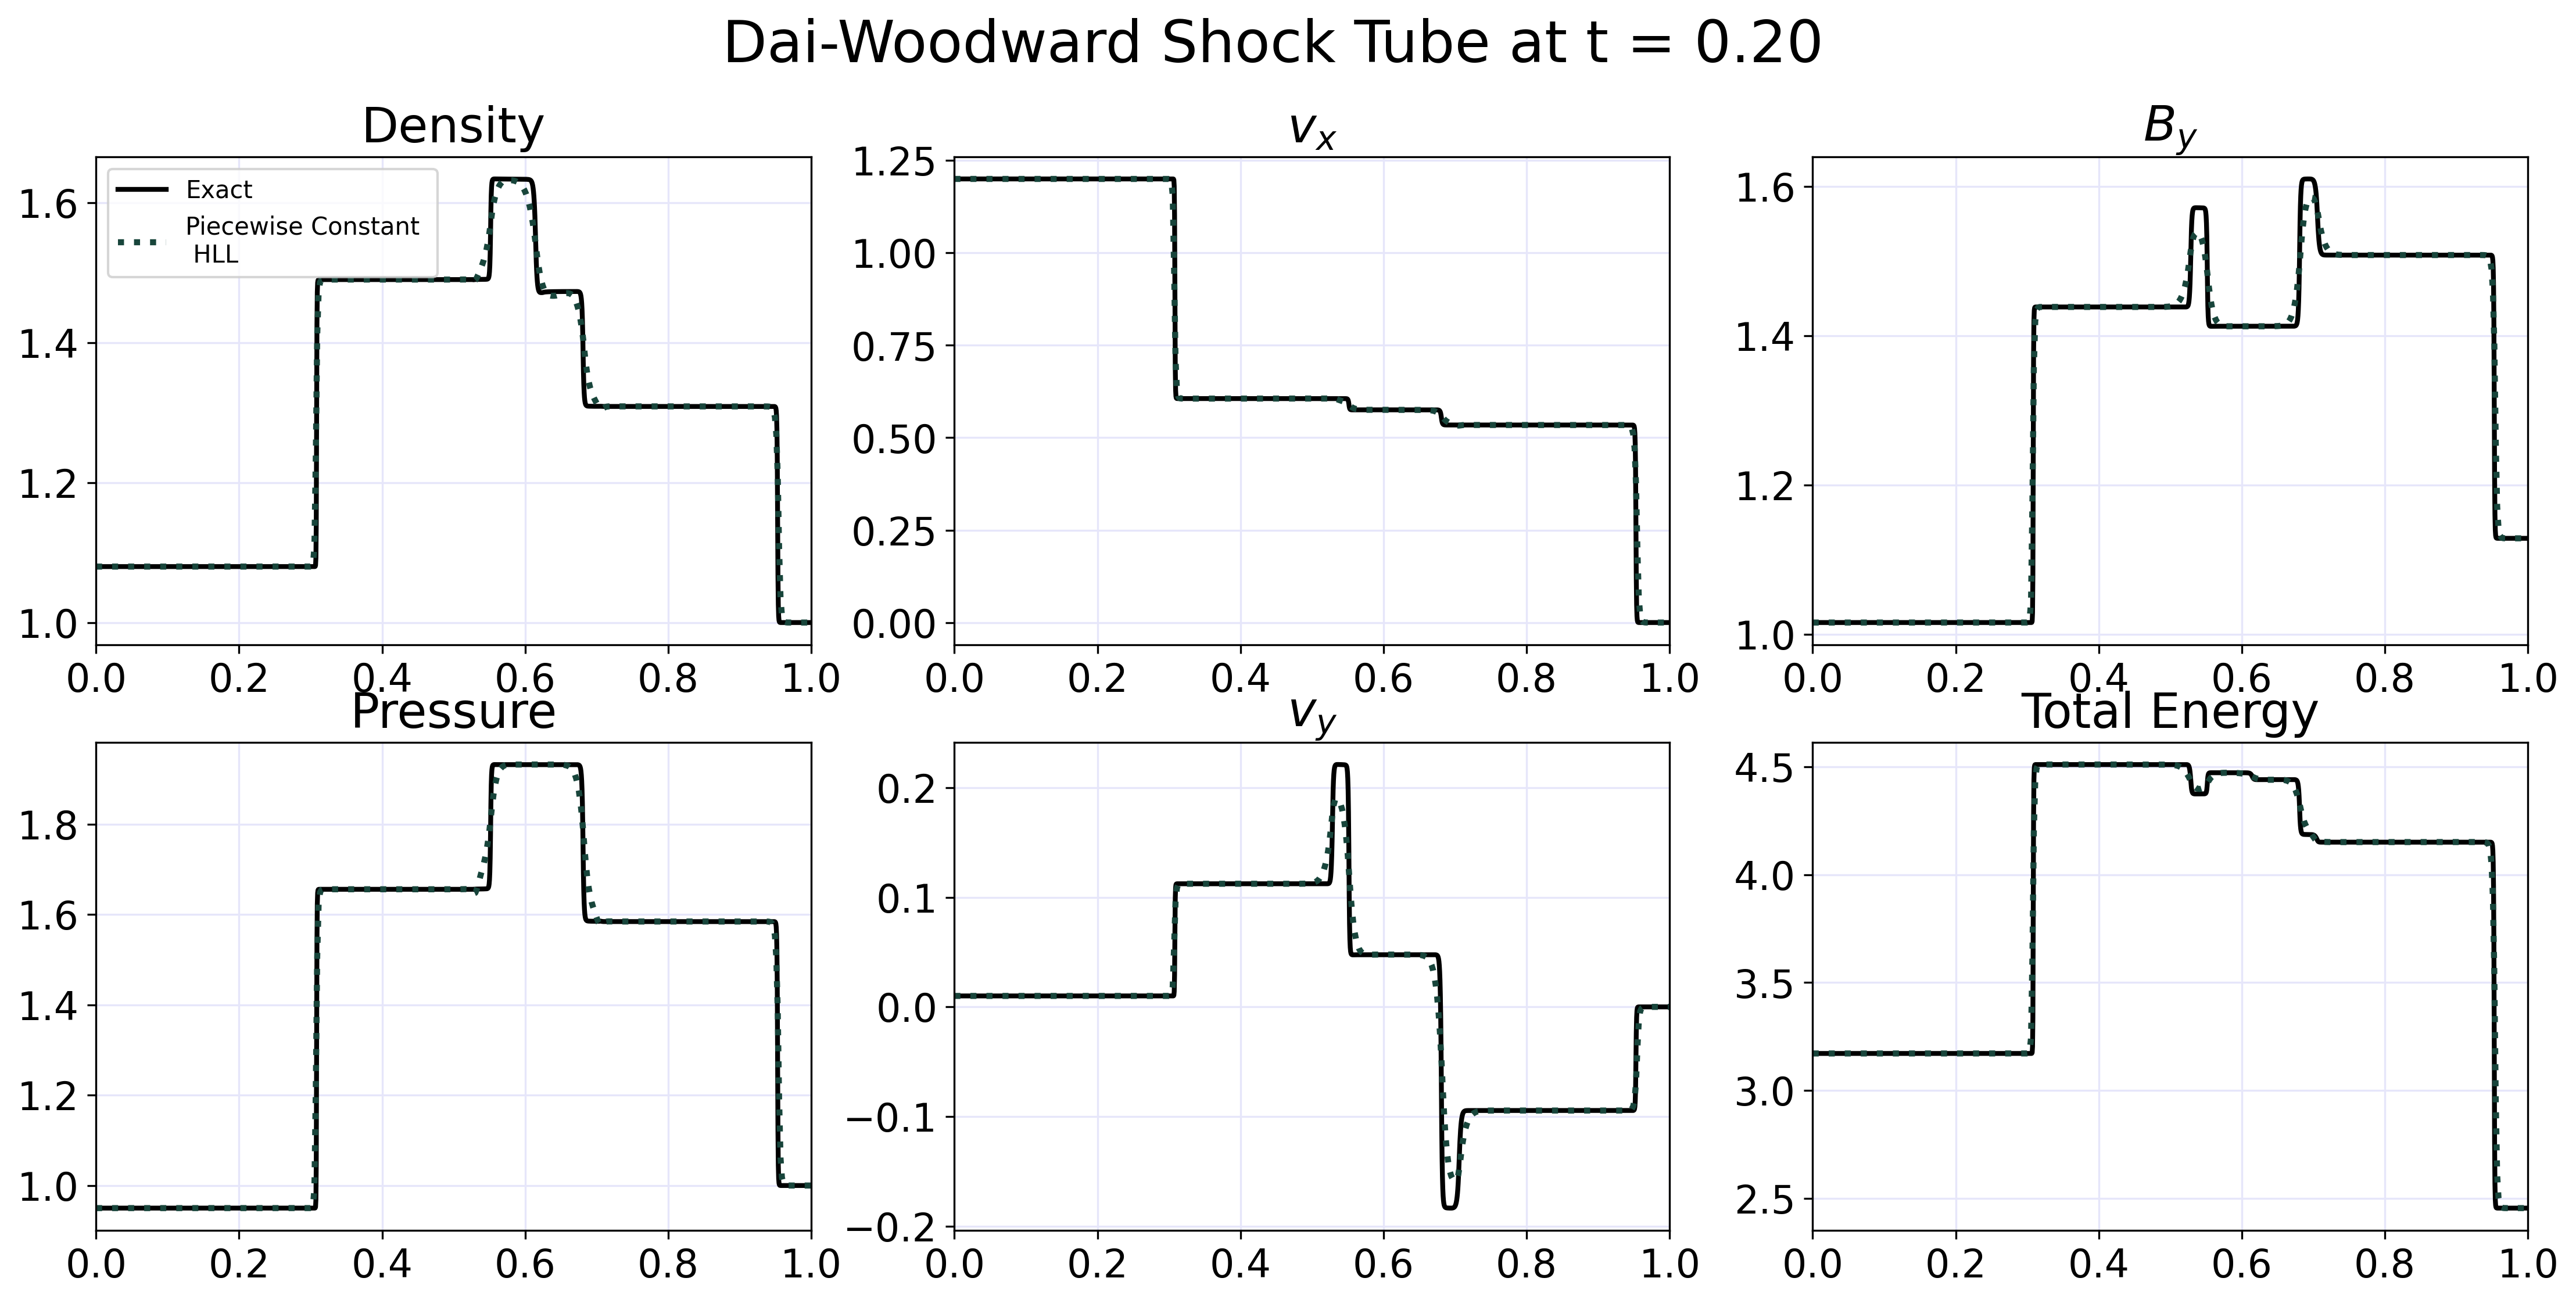

In [36]:
# Dai Woodward problem setting up variables and visualizing

DOFs_MHD_1D = 8
nx = 512
dx = 1/nx
C = 0.1
#Brio-Wu
gamma = 5/3
tf = 0.2

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_DW = np.array([Dai_Woodward(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_DW = U_IC_DW.T # shape (DOF, nx)
U_ghost_IC_DW = np.zeros((DOFs_MHD_1D, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_DW[:, nghost:nghost+nx] = U_IC_DW # ghosted vector able to have BCs


U_Sol_DW_g1_HLL, all_solns_DW_g1_HLL, all_t_DW_g1_HLL    = evolve(U_ghost_IC_DW, nx, C, tf, gamma, Riemann_HLL, Godunov_type=1)


plot_solution(X, U_Sol_DW_g1_HLL, tf, gamma, 'Dai-Woodward', 'Piecewise Constant', 'HLL')